# Deep Reinforcement Lerning Lectures - Policy Gradients

### Imports and auxiliary settings

In [25]:
 # -------- OS / Colab detection --------
import os
import sys
import platform
import subprocess

OS_NAME = platform.system()   # "Windows", "Linux", "Darwin"
IN_COLAB = True

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

print("OS:", OS_NAME, "| Colab:", IN_COLAB)

if IN_COLAB:
  !apt update
  !apt install -y xvfb x11-utils python3-opengl ffmpeg swig
  !pip install swig
  !pip install jax==0.7.2 jaxlib==0.7.2
  !pip install gymnasium==1.2.3 gymnasium[box2d] pyvirtualdisplay imageio-ffmpeg moviepy==1.0.3
  !pip install onnx==1.20.0 onnx2pytorch==0.5.3
  !pip install numpy==2.4.2
  # SELF ADDED
  !pip install onnxscript

# -------- Device selection --------
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

OS: Linux | Colab: True
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Ign:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Ign:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Ign:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Ign:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Ign:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Ign:11 https://ppa.launchpadcontent.ne

In [ ]:
from google.colab import drive

# First, attempt to unmount if it's already mounted to ensure a clean state.
try:
  drive.flush_and_unmount()
except ValueError:
  pass # Drive was not mounted, so nothing to unmount.

# Ensure the mount point directory exists and is empty.
# If it's not empty after unmounting, manually remove contents.
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
  if os.listdir('/content/drive'):
    print("Mountpoint /content/drive is not empty. Clearing contents...")
    !rm -rf /content/drive/*
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)

# Now, try to mount Google Drive.
drive.mount('/content/drive', force_remount=True)

In [3]:
%matplotlib inline

# PyTorch imports
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader

# ONNX imports
import onnx
from onnx2pytorch import ConvertModel

# Auxiliary Python imports
import math
import io
import base64
import random
import shutil
import copy
import glob
from time import time, strftime, sleep

import numpy as np
from tqdm.notebook import tqdm

# Colab utilities
from google.colab import files

# Environment imports
import gymnasium as gym
from gymnasium.spaces import Box
from gymnasium import logger as gymlogger
from gymnasium.wrappers import RecordVideo

gymlogger.min_level = gymlogger.ERROR

# Plotting and notebook imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from IPython.display import HTML, display, clear_output

# -------- Virtual display --------
pydisplay = None

if OS_NAME == "Linux":
    try:
        from pyvirtualdisplay import Display
        pydisplay = Display(visible=0, size=(640, 480))
        pydisplay.start()
        print("Virtual display started.")
    except Exception as e:
        print("Skipping virtual display:", e)
else:
    print(f"Skipping virtual display on {OS_NAME}.")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Virtual display started.
Device: cuda


### Auxiliary Methods

In [4]:
class Logger(object):
    """Logger that can be used for debugging different values
    """
    def __init__(self, logdir, params=None, debug=False):
        self.gradients = []
        self.debug = debug
        self.basepath = os.path.join(logdir, strftime("%Y-%m-%dT%H-%M-%S"))
        os.makedirs(self.basepath, exist_ok=True)
        os.makedirs(self.log_dir, exist_ok=True)
        if params is not None and os.path.exists(params):
            shutil.copyfile(params, os.path.join(self.basepath, "params.pkl"))
        self.log_dict = {}
        self.dump_idx = {}

    def add_gradients(self, grad):
        if not self.debug: return
        self.gradients.append(grad)

    def compute_gradient_variance(self):
        vars_ = []
        grads_list = [np.zeros_like(self.gradients[0])] * 100
        for i, grads in enumerate(self.gradients):
            grads_list.append(grads)
            grads_list = grads_list[1:]
            grad_arr = np.stack(grads_list, axis=0)
            g = np.apply_along_axis(grad_variance, axis=-1, arr=grad_arr)
            vars_.append(np.mean(g))
        return vars_

    @property
    def param_file(self):
        return os.path.join(self.basepath, "params.pkl")

    @property
    def onnx_file(self):
        return os.path.join(self.basepath, "model.onnx")

    @property
    def video_dir(self):
        return os.path.join(self.basepath, "videos")

    @property
    def log_dir(self):
        return os.path.join(self.basepath, "logs")

    def log(self, name, value):
        if name not in self.log_dict:
            self.log_dict[name] = []
            self.dump_idx[name] = -1
        self.log_dict[name].append((len(self.log_dict[name]), time(), value))

    def get_values(self, name):
        if name in self.log_dict:
            return [x[2] for x in self.log_dict[name]]
        return None

    def dump(self):
        for name, rows in self.log_dict.items():
            with open(os.path.join(self.log_dir, name + ".log"), "a") as f:
                for i, row in enumerate(rows):
                    if i > self.dump_idx[name]:
                        f.write(",".join([str(x) for x in row]) + "\n")
                        self.dump_idx[name] = i

In [5]:
def wrap_env(env, logger, capture_video=True):
    # wrapper for recording
    env = gym.wrappers.RecordEpisodeStatistics(env)
    if capture_video:
        env = gym.wrappers.RecordVideo(env, logger.video_dir, episode_trigger=lambda idx: True)
    return env


def create_env(logger, env_id='BipedalWalker-v3', hardcore=False, capture_video=True):
    # initialize environment
    env = wrap_env(gym.make(env_id, max_episode_steps=2000, hardcore=hardcore, render_mode="rgb_array"), # SELF changed 2000 from 400
                   logger=logger,
                   capture_video=capture_video)
    action_size = env.action_space.shape[0]
    state_size = env.observation_space.shape[0]
    return env, action_size, state_size


def set_seed(env, seed=None):
    # seeding the envrionment
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


def transforms(state):
    # transofrm to numpy to tensor and push to device
    return torch.FloatTensor(state).to(device)


def test_environment(env, agent=None, seed=42, n_steps=200):
    # run and evaluate in the environment
    state, info = env.reset(seed=seed)
    for i in range(n_steps):
        env.render()

        if agent is None:
            action = env.action_space.sample()
        else:
            action, _ = agent.act(state)
            action = action.squeeze().cpu().numpy()
        state, reward, done, truncated, info = env.step(action)
        if done:
            state, info = env.reset(seed=seed)
    env.close()


def get_running_stat(stat, stat_len):
    # evaluate stats
    cum_sum = np.cumsum(np.insert(stat, 0, 0))
    return (cum_sum[stat_len:] - cum_sum[:-stat_len]) / stat_len


def plot_results(runner):
    # plot stats
    episode, r, l = np.array(runner.stats_rewards_list).T
    cum_r = get_running_stat(r, 10)
    cum_l = get_running_stat(l, 10)

    plt.figure(figsize=(16, 16))

    plt.subplot(321)

    # plot rewards
    plt.plot(episode[-len(cum_r):], cum_r)
    plt.plot(episode, r, alpha=0.5)
    plt.xlabel('Episode')
    plt.ylabel('Episode Reward')

    plt.subplot(322)

    # plot episode lengths
    plt.plot(episode[-len(cum_l):], cum_l)
    plt.plot(episode, l, alpha=0.5)
    plt.xlabel('Episode')
    plt.ylabel('Episode Length')

    plt.subplot(323)

    # plot return
    all_returns = np.array(runner.buffer.all_returns)
    plt.scatter(range(0, len(all_returns)), all_returns, alpha=0.5)
    mean_returns = np.array(runner.buffer.mean_returns)
    plt.plot(range(0, len(mean_returns)), mean_returns, color="orange")
    plt.xlabel('Episode')
    plt.ylabel('Return')

    plt.subplot(324)

    # plot entropy
    entropy_arr = np.array(runner.stats_entropy_list)
    plt.plot(range(0, len(entropy_arr)), entropy_arr)
    plt.xlabel('Episode')
    plt.ylabel('Entropy')

    plt.subplot(325)

    if runner.logger.debug:
        # plot variance
        variance_arr = np.array(runner.logger.compute_gradient_variance())
        plt.plot(range(0, len(variance_arr)), variance_arr)
        plt.xlabel('Episode')
        plt.ylabel('Variance')

    plt.show()


"""
Utility functions to enable video recording of gym environment and displaying it
"""
def show_video(logger):
    print(logger.video_dir)
    mp4list = glob.glob(f'{logger.video_dir}/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data='''<video alt="test" autoplay
                  loop controls style="height: 400px;">
                  <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")


def grad_variance(g):
    # compute gradient variance
    return np.mean(g**2) - np.mean(g)**2

### Test environment

OpenAI offers a set of environments for Reinforcement Learning, which are accessible via the `gymnasium` pip package.
In this exercise we will focus on discrete control tasks using a Box2D simulation known as BipedalWalker-v3.
To access the Box2D packages, we use the gymnasium pypi `box2d` option.

In [6]:
# show behavior in envrionment with random agent
logger = Logger("logdir")
env, _, _ = create_env(logger)
test_environment(env)
show_video(logger)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


logdir/2026-05-01T15-25-17/videos


### Training Buffer

In [7]:
class Transition(object):
    """Single rollout transition."""
    def __init__(self, state, action, reward, next_state, log_probs, done=False):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.log_probs = log_probs

        # Used by GAE.
        self.done = done
        self.advantage = 0.0
        self.g_return = 0.0


class Episode(object):
    """Collects transitions for one episode."""
    def __init__(self, discount):
        self.discount = discount
        self._empty()
        self.total_reward = 0.0

    def _empty(self):
        self.n = 0
        self.transitions = []

    def reset(self):
        self._empty()

    def size(self):
        return self.n

    def append(self, transition):
        self.transitions.append(transition)
        self.n += 1

    def states(self):
        return [t.state for t in self.transitions]

    def actions(self):
        return [t.action for t in self.transitions]

    def rewards(self):
        return [t.reward for t in self.transitions]

    def next_states(self):
        return [t.next_state for t in self.transitions]

    def returns(self):
        return [t.g_return for t in self.transitions]

    def calculate_return(self):
        rewards = self.rewards()
        trajectory_len = len(rewards)

        return_array = torch.zeros((trajectory_len,))
        g_return = 0.0

        for i in range(trajectory_len - 1, -1, -1):
            g_return = rewards[i] + self.discount * g_return
            return_array[i] = g_return
            self.transitions[i].g_return = g_return

        return return_array


class BufferDataset(Dataset):
    """Dataset wrapper for rollout buffer samples."""
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        t = self.data[idx]

        return (
            t.state,
            t.action,
            t.reward,
            t.next_state,
            t.log_probs,
            torch.tensor(t.g_return, dtype=torch.float32),
            torch.tensor(t.advantage, dtype=torch.float32),
        )


class RolloutBuffer(object):
    """Stores rollout transitions and computes GAE."""
    def __init__(self, capacity, batch_size, min_transitions):
        self.capacity = capacity
        self.batch_size = batch_size
        self.min_transitions = min_transitions

        self.buffer = []
        self._empty()

        self.mean_returns = []
        self.all_returns = []

    def _empty(self):
        del self.buffer[:]
        self.position = 0

    def add(self, episode):
        episode.calculate_return()

        for t in episode.transitions:
            if len(self.buffer) < self.capacity:
                self.buffer.append(None)

            self.buffer[self.position] = t
            self.position = (self.position + 1) % self.capacity

    def update_stats(self):
        returns = [t.g_return for t in self.buffer]
        self.all_returns += returns

        mean_return = np.mean(np.array(returns))
        self.mean_returns += [mean_return] * len(returns)

    def reset(self):
        self._empty()

    def create_dataloader(self):
        return DataLoader(
            BufferDataset(self.buffer),
            batch_size=self.batch_size,
            shuffle=True,
            drop_last=True
        )

    def compute_gae(self, critic, gamma=0.99, gae_lambda=0.95):
        """Computes Generalized Advantage Estimation."""
        critic.eval()

        with torch.no_grad():
            states = torch.stack([t.state for t in self.buffer]).float().to(device)
            next_states = torch.stack([t.next_state for t in self.buffer]).float().to(device)
            rewards = torch.stack([t.reward for t in self.buffer]).float().to(device).view(-1, 1)
            dones = torch.tensor(
                [t.done for t in self.buffer],
                dtype=torch.float32
            ).to(device).view(-1, 1)

            values = critic(states)
            next_values = critic(next_states)

            advantages = torch.zeros_like(rewards).to(device)
            gae = torch.zeros(1, 1).to(device)

            for i in reversed(range(len(self.buffer))):
                mask = 1.0 - dones[i]
                delta = rewards[i] + gamma * next_values[i] * mask - values[i]
                gae = delta + gamma * gae_lambda * mask * gae
                advantages[i] = gae

            returns = advantages + values

        advantages = advantages.cpu()
        returns = returns.cpu()

        for i, t in enumerate(self.buffer):
            t.advantage = advantages[i].item()
            t.g_return = returns[i].item()

    def __len__(self):
        return len(self.buffer)

### Define Models

In [8]:
class ActorNet(nn.Module):
    """Actor network producing Normal policy logits."""
    def __init__(self, state_size, action_size, hidden_size):
        super(ActorNet, self).__init__()

        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        self.mu_head = nn.Linear(hidden_size, action_size)

        # Kept for backward compatibility with older checkpoints.
        # It is not used in forward() anymore.
        self.sigma_head = nn.Linear(hidden_size, action_size)

        # Global trainable sigma logits are more stable than state-dependent sigma.
        self.log_std_logits = nn.Parameter(torch.ones(action_size) * -1.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        mu_logits = self.mu_head(x)

        sigma_logits = self.log_std_logits.unsqueeze(0).expand_as(mu_logits)
        sigma_logits = torch.clamp(sigma_logits, min=-5.0, max=0.5)

        return mu_logits, sigma_logits


class CriticNet(nn.Module):
    """Critic network estimating V(s)."""
    def __init__(self, state_size, action_size, hidden_size):
        super(CriticNet, self).__init__()

        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.value_head(x)


class ActorCriticNet(nn.Module):
    """Combined actor-critic model."""
    def __init__(self, state_size, action_size, hidden_size):
        super(ActorCriticNet, self).__init__()

        self.actor = ActorNet(state_size, action_size, hidden_size)
        self.critic = CriticNet(state_size, action_size, hidden_size)

    def forward(self, x):
        x = x.reshape(1, -1)
        return self.act(x)

    def act(self, state):
        if not torch.is_tensor(state):
            state = transforms(state)

        if state.dim() == 1:
            state = state.unsqueeze(0)

        mu_logits, sigma_logits = self.actor(state)

        mu = F.tanh(mu_logits)
        sigma = F.softplus(sigma_logits) + 1e-5

        dist = Normal(mu, sigma)

        action = dist.sample()
        action = torch.clamp(action, -1.0, 1.0)

        log_probs = dist.log_prob(action)
        log_probs = log_probs.sum(dim=-1, keepdim=True)

        return action, log_probs

    def evaluate(self, state, action):
        if state.dim() == 1:
            state = state.unsqueeze(0)

        if action.dim() == 1:
            action = action.unsqueeze(0)

        mu_logits, sigma_logits = self.actor(state)

        mu = F.tanh(mu_logits)
        sigma = F.softplus(sigma_logits) + 1e-5

        dist = Normal(mu, sigma)

        log_probs = dist.log_prob(action)
        log_probs = log_probs.sum(dim=-1, keepdim=True)

        entropy = dist.entropy()
        entropy = entropy.sum(dim=-1, keepdim=True)

        state_value = self.critic(state)

        return log_probs, state_value, entropy

In [9]:
# SELF ADDED

class ActorONNXWrapper(nn.Module):
    """Wrapper used to make ONNX outputs compatible with onnx2pytorch."""
    def __init__(self, actor, sigma_shift=0.0):
        super().__init__()
        self.actor = actor
        self.sigma_shift = sigma_shift

    def forward(self, x):
        mu, sigma = self.actor(x)

        # Optional export-only sigma adjustment.
        sigma = sigma + self.sigma_shift

        # Force both outputs to depend on the input tensor.
        # This prevents onnx2pytorch from treating them as constants.
        anchor = 0.0 * x.sum(dim=1, keepdim=True)

        mu = mu + anchor.expand_as(mu)
        sigma = sigma + anchor.expand_as(sigma)

        return mu, sigma

### Define Agent

In [33]:
class Agent(object):
    """Agent used for training, checkpointing, and ONNX export."""
    def __init__(
        self,
        buffer,
        state_size,
        action_size,
        hidden_size,
        learning_rate,
        logger,
        eps_clip,
        n_epochs,
        weight_decay,
        betas,
        loss_scales,
        discount,
        checkpoint_dir="ckpts"
    ):
        self.action_size = action_size
        self.state_size = state_size
        self.buffer = buffer
        self.checkpoint_dir = checkpoint_dir
        self.loss_scales = loss_scales
        self.n_epochs = n_epochs
        self.eps_clip = eps_clip
        self.logger = logger
        self.discount = discount

        self.model = ActorCriticNet(
            state_size=state_size,
            action_size=action_size,
            hidden_size=hidden_size
        ).to(device)

        self.optimizer = optim.AdamW(
            [
                {
                    "params": self.model.actor.parameters(),
                    "lr": learning_rate
                },
                {
                    "params": self.model.critic.parameters(),
                    "lr": learning_rate * 2.0
                }
            ],
            betas=betas,
            weight_decay=weight_decay
        )

    def save_checkpoint(self, epoch, info=""):
        state = {
            "info": info,
            "epoch": epoch,
            "state_dict": self.model.state_dict(),
            "optimizer": self.optimizer.state_dict()
        }

        os.makedirs(self.checkpoint_dir, exist_ok=True)

        ckp_name = "best-checkpoint.pth" if info == "best" else f"checkpoint-epoch{epoch}.pth"
        filename = os.path.join(self.checkpoint_dir, ckp_name)

        torch.save(state, filename)

    def resume_checkpoint(self, resume_path):
        print(f"Loading checkpoint: {resume_path} ...")

        checkpoint = torch.load(resume_path, map_location=device)

        self.model.load_state_dict(checkpoint["state_dict"])
        self.model = self.model.to(device)

        try:
            self.optimizer.load_state_dict(checkpoint["optimizer"])
        except Exception as e:
            print("Optimizer state could not be loaded:", e)

        print("Checkpoint loaded. Resume training")

    def load_onnx_checkpoint(self, onnx_file):
        self.model.actor = ConvertModel(onnx.load(onnx_file)).to(device)
        self.model.eval()

    def save_onnx_checkpoint(self, onnx_path=None, sigma_shift=0.0):
        """Exports the actor as ONNX on CPU."""
        if onnx_path is None:
            onnx_path = os.path.join(self.checkpoint_dir, "model.onnx")

        os.makedirs(os.path.dirname(onnx_path), exist_ok=True)

        original_device = next(self.model.parameters()).device
        export_device = torch.device("cpu")

        dummy_input = torch.randn((1, self.state_size), device=export_device)

        actor = self.model.actor.to(export_device)
        actor.eval()

        model = ActorONNXWrapper(actor, sigma_shift=sigma_shift).to(export_device)
        model.eval()

        print("dummy device:", dummy_input.device)
        print("model device:", next(model.parameters()).device)
        print("sigma_shift:", sigma_shift)

        torch.onnx.export(
            model,
            dummy_input,
            onnx_path,
            verbose=False,
            opset_version=18,
            export_params=True,
            do_constant_folding=False,
            input_names=["state"],
            output_names=["mu", "sigma"],
            dynamo=False,
        )

        # Move the model back to its original device after export.
        self.model = self.model.to(original_device)
        self.model.eval()

        print(f"ONNX model saved to: {onnx_path}")

    def check(self, file_name):
        model = onnx.load(file_name)
        onnx.checker.check_model(model)

    def act(self, state):
        if not torch.is_tensor(state):
            state = transforms(state)

        state = state.float().to(device)

        if state.dim() == 1:
            state = state.unsqueeze(0)

        with torch.no_grad():
            action, log_probs = self.model.act(state)

        return action, log_probs

    def train(self):
        self.buffer.compute_gae(
            critic=self.model.critic,
            gamma=self.discount,
            gae_lambda=0.95
        )

        for i in range(self.n_epochs):
            loader = self.buffer.create_dataloader()

            for states, actions, rewards, next_states, old_log_probs, returns, advantages in loader:
                states = states.float().to(device)
                actions = actions.float().to(device)
                old_log_probs = old_log_probs.float().to(device).view(-1, 1)

                returns = returns.float().to(device).view(-1, 1)
                advantages = advantages.float().to(device).view(-1, 1)

                adv_mean = advantages.mean()
                adv_std = advantages.std(unbiased=False)

                if torch.isfinite(adv_std) and adv_std > 1e-8:
                    advantages = (advantages - adv_mean) / (adv_std + 1e-8)
                else:
                    advantages = advantages - adv_mean

                log_probs, state_values, entropy = self.model.evaluate(states, actions)

                ratios = torch.exp(log_probs - old_log_probs.detach())

                surrogate_1 = ratios * advantages
                surrogate_2 = torch.clamp(
                    ratios,
                    1.0 - self.eps_clip,
                    1.0 + self.eps_clip
                ) * advantages

                policy_loss = -torch.min(surrogate_1, surrogate_2).mean()
                value_loss = F.mse_loss(state_values, returns.detach())
                entropy_loss = entropy.mean()

                value_scale = self.loss_scales[0]
                entropy_scale = self.loss_scales[1]

                loss = policy_loss + value_scale * value_loss - entropy_scale * entropy_loss

                if not torch.isfinite(loss):
                    print("Skipping update because loss is not finite.")
                    continue

                self.optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)

                self.optimizer.step()

        return (
            loss.mean().detach().cpu().numpy(),
            value_loss.mean().detach().cpu().numpy(),
            policy_loss.mean().detach().cpu().numpy()
        ), entropy.mean().detach().cpu().numpy()

### Define Task Runner

In [11]:
class Runner(object):
    """Collects rollouts and periodically trains the agent."""
    def __init__(
        self,
        env,
        agent,
        buffer,
        logger,
        discount=0.99,
        n_episodes=4000,
        reward_scale=lambda x: x,
        use_buffer_reset=True,
        stats_interval=1,
        print_stats=True,
        min_average_reward=300,
        render=False,
        seed=42,
        checkpoint_interval=100,
        max_episode_steps=2000,
        randomize_seeds=True,
        fall_penalty=5.0
    ):
        self.env = env
        self.agent = agent
        self.buffer = buffer
        self.render = render
        self.logger = logger
        self.discount = discount
        self.n_episodes = n_episodes
        self.reward_scale = reward_scale
        self.use_buffer_reset = use_buffer_reset
        self.stats_interval = stats_interval
        self.print_stats = print_stats
        self.min_average_reward = min_average_reward
        self.seed = seed
        self.max_episode_steps = max_episode_steps
        self.randomize_seeds = randomize_seeds
        self.fall_penalty = fall_penalty

        self.stats_rewards_list = []
        self.stats_entropy_list = []

        self.timesteps = 0
        self.checkpoint_interval = checkpoint_interval
        self.best_model = None
        self.max_reward = -np.inf
        self.best_avg_reward = -np.inf

    def run(self):
        self.agent.model.eval()

        with tqdm(range(self.n_episodes)) as pbar:
            for e in pbar:
                if self.randomize_seeds:
                    state, info = self.env.reset(seed=None)
                else:
                    state, info = self.env.reset(seed=self.seed + e)

                total_losses = 0.0
                value_losses = 0.0
                policy_losses = 0.0

                episode = Episode(discount=self.discount)

                if e % self.checkpoint_interval == 0:
                    self.agent.save_checkpoint(e)

                done = False

                while not done:
                    self.timesteps += 1

                    if self.render:
                        self.env.render()

                    action, log_probs = self.agent.act(state)
                    action_np = action.squeeze(0).detach().cpu().numpy()

                    next_state, reward, done, truncated, info = self.env.step(action_np)

                    if truncated or episode.size() + 1 >= self.max_episode_steps:
                        done = True

                    scaled_reward = self.reward_scale(reward)

                    # Penalize early falls during training only.
                    if done and episode.size() + 1 < self.max_episode_steps:
                        scaled_reward -= self.fall_penalty

                    transition = Transition(
                        state=transforms(state).detach().cpu(),
                        action=action.squeeze(0).detach().cpu(),
                        reward=torch.tensor(scaled_reward, dtype=torch.float32),
                        next_state=transforms(next_state).detach().cpu(),
                        log_probs=log_probs.detach().cpu(),
                        done=done
                    )

                    episode.append(transition)
                    episode.total_reward += reward

                    state = next_state

                    if done:
                        self.buffer.add(episode)

                        if len(self.buffer) >= self.buffer.min_transitions:
                            self.agent.model.train()

                            losses, entropy = self.agent.train()

                            self.agent.model.eval()

                            total_losses += losses[0]
                            value_losses += losses[1]
                            policy_losses += losses[2]

                            self.stats_entropy_list.append(entropy)

                            self.buffer.update_stats()

                            self.logger.log("total_loss", losses[0])
                            self.logger.log("value_loss", losses[1])
                            self.logger.log("policy_loss", losses[2])
                            self.logger.log("entropy", entropy)

                            if self.use_buffer_reset:
                                self.buffer.reset()

                    if done:
                        self.stats_rewards_list.append((e, episode.total_reward, episode.size()))

                        self.logger.log("episode_reward", episode.total_reward)
                        self.logger.log("episode_length", episode.size())
                        self.logger.dump()

                        if len(self.stats_rewards_list) >= 10:
                            avg_reward = np.mean([x[1] for x in self.stats_rewards_list[-10:]])
                        else:
                            avg_reward = episode.total_reward

                        pbar.set_description(
                            f"Ep {e} | R {episode.total_reward:.1f} | Avg10 {avg_reward:.1f} | Len {episode.size()}"
                        )

                        if self.print_stats and e % self.stats_interval == 0:
                            print(
                                f"Episode {e:5d} | "
                                f"Reward: {episode.total_reward:8.2f} | "
                                f"Avg10: {avg_reward:8.2f} | "
                                f"Length: {episode.size():4d}"
                            )

                        # Save best checkpoint by Avg10, not by a single lucky episode.
                        if avg_reward > self.best_avg_reward and len(self.stats_rewards_list) >= 10:
                            self.best_avg_reward = avg_reward
                            self.best_model = copy.deepcopy(self.agent.model)
                            self.agent.save_checkpoint(e, "best")
                            print(f"New best Avg10 checkpoint: {avg_reward:.2f}")

### Train Agent

This is a where you run your actor-critic PPO algorithm.

Some tips as to what you need to implement:
- chose proper architectures for the actor-critic networks
- choose the appropriate loss function (think on which kind of problem you are solving)
- choose an optimizer and its hyper-parameters
- optional: use a learning-rate scheduler
- store your model and training progress often so you don't loose progress if your program crashes

In case you use the provided Logger:
- `logger.log("training_loss", <loss-value>)` to log a particular value
- `logger.dump()` to write the current logs to a log file (e.g. after every episode)
- `logger.log_dir`, `logger.param_file`, `logger.onnx_file`, `logger.video_dir` point to files or directories you can use to save files
- you might want to specify your google drive folder as a logdir in order to automatically sync your results
- if you log the metrics specified in the `plot_metrics` function you can use it to visualize your training progress (or take it as a template to plot your own metrics)

In [35]:
# create environment
logger = Logger("logdir")
env, action_size, state_size = create_env(logger, capture_video=False)

seed = 31
# set seed
set_seed(env, seed=seed)

# ===================================================
# ++++++++++++++++ YOUR CODE HERE +++++++++++++++++++
# ===================================================
# > find suitable hyperparameters
# hyperparameters
episodes = 1500 # run agent for this many episodes
epochs = 3 # run n epochs of network updates # tried 4 and 6 and 5
hidden_size = 128 # number of units in NN hidden layers
learning_rate = 3e-5 # learning rate for optimizer # tried 1e-4 and 2e-4
discount = 0.99 # discount factor gamma value
reward_scale = lambda x: x / 10.0 # reward scaling #ADDED /10.0

batch_size = 64 # number of samples used for an update
min_transitions = 1024 # number of minimum transitions until update is triggered # tried 2048 and 4096
capacity = 2048 # maximum number of transitions stored in the rollout buffer # tried 4096 and 8192

use_buffer_reset = True # resets the buffer after every update
eps_clip = 0.1 # clipping or importance sampling updates # tried 0.2
loss_scales = (0.7, 0.001) # loss scales (value loss, policy loss, entropy loss) # tried (0.5, 0.005) (0.5, 0.003) (0.5, 0.001)
betas = (0.9, 0.999) # optimizer beta parameters
weight_decay = 0.0 # optimizer weight decay
checkpoint_interval = 50 # checkpoint interval to overwrite the parameters

#SELF ADDED
checkpoint_dir = "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13"

# additional settings
print_stats = True
render = False # CHANGED TO FALSE

In [36]:
buffer = RolloutBuffer(capacity=capacity, batch_size=batch_size, min_transitions=min_transitions)
# SELF ADDED
# checkpoint dir, randomize seeds, fall penalty
agent = Agent(buffer=buffer, state_size=state_size, action_size=action_size, hidden_size=hidden_size,
              learning_rate=learning_rate, logger=logger, eps_clip=eps_clip, n_epochs=epochs, weight_decay=weight_decay, betas=betas, loss_scales=loss_scales, discount=discount, checkpoint_dir=checkpoint_dir)
#
# SELF ADDED
#agent.resume_checkpoint("/content/drive/MyDrive/ppo_bipedal_ckpts/GAE/checkpoint-epoch2000.pth")
#agent.resume_checkpoint("/content/drive/MyDrive/ppo_bipedal_ckpts/best-checkpoint.pth")
agent.resume_checkpoint("/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch300.pth")
runner = Runner(env=env, agent=agent, buffer=buffer, logger=logger, discount=discount, n_episodes=episodes, reward_scale=reward_scale,
                use_buffer_reset=use_buffer_reset, print_stats=print_stats, render=render, seed=seed, randomize_seeds=True, fall_penalty=5.0)

Loading checkpoint: /content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch300.pth ...
Checkpoint loaded. Resume training


In [ ]:
runner.run()

  0%|          | 0/1500 [00:00<?, ?it/s]

Episode     0 | Reward:   184.72 | Avg10:   184.72 | Length: 2000
Episode     1 | Reward:   195.04 | Avg10:   195.04 | Length: 2000
Episode     2 | Reward:   184.39 | Avg10:   184.39 | Length: 2000
Episode     3 | Reward:   206.17 | Avg10:   206.17 | Length: 2000
Episode     4 | Reward:   -56.55 | Avg10:   -56.55 | Length:  275
Episode     5 | Reward:   213.04 | Avg10:   213.04 | Length: 2000
Episode     6 | Reward:   -52.34 | Avg10:   -52.34 | Length:  234
Episode     7 | Reward:   -92.37 | Avg10:   -92.37 | Length:  156
Episode     8 | Reward:   188.13 | Avg10:   188.13 | Length: 2000
Episode     9 | Reward:   202.16 | Avg10:   117.24 | Length: 2000
New best Avg10 checkpoint: 117.24
Episode    10 | Reward:    16.72 | Avg10:   100.44 | Length:  675
Episode    11 | Reward:   234.23 | Avg10:   104.36 | Length: 2000
Episode    12 | Reward:   -97.30 | Avg10:    76.19 | Length:  158
Episode    13 | Reward:   -67.29 | Avg10:    48.85 | Length:  191
Episode    14 | Reward:  -100.06 | Avg10: 

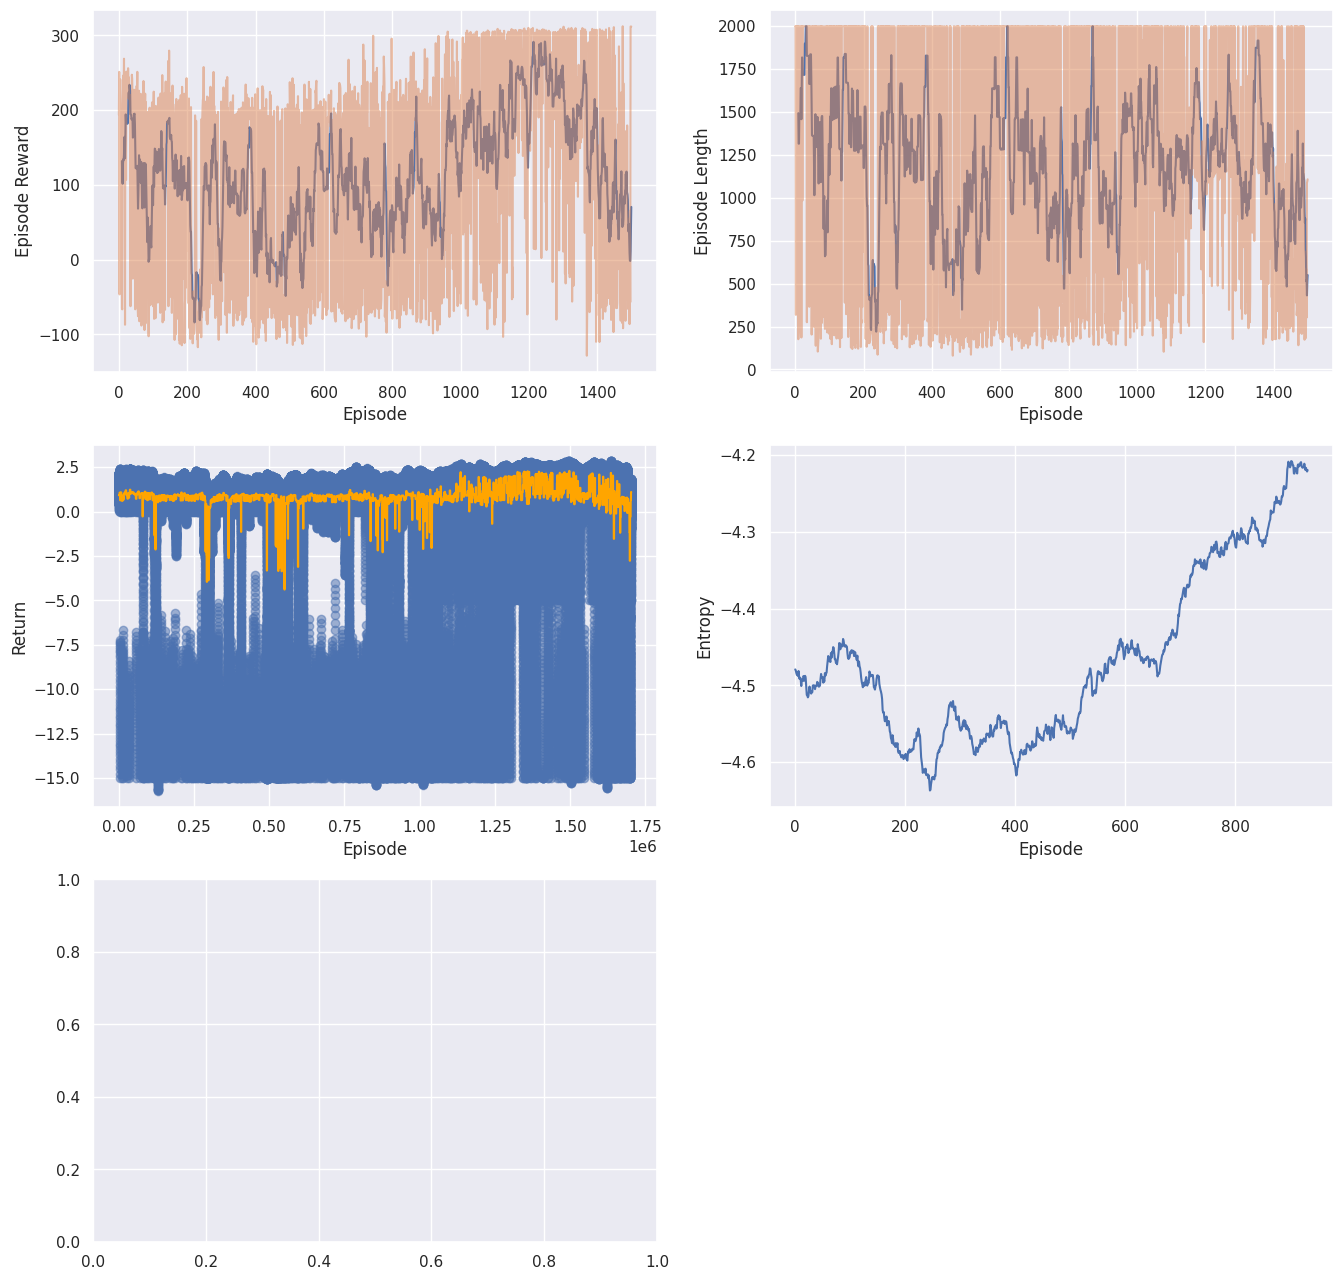

In [15]:
plot_results(runner)

In [16]:
with torch.no_grad():
    dummy_state = torch.randn(1, state_size).to(device)
    mu_logits, sigma_logits = agent.model.actor(dummy_state)
    sigma = F.softplus(sigma_logits) + 1e-5

print("sigma_logits:", sigma_logits.detach().cpu().numpy())
print("sigma:", sigma.detach().cpu().numpy())
print("sigma mean:", sigma.mean().item())
print("sigma min:", sigma.min().item())
print("sigma max:", sigma.max().item())

sigma_logits: [[-2.2374487 -2.5395598 -2.1642773 -2.7803137]]
sigma: [[0.10142013 0.07595304 0.10871452 0.06018186]]
sigma mean: 0.08656738698482513
sigma min: 0.06018185615539551
sigma max: 0.1087145209312439


In [17]:
eval_device = torch.device("cpu")


class EvalEnv:
    """Environment wrapper matching the official evaluation script."""
    def __init__(self):
        self.gym_env = gym.make("BipedalWalker-v3", hardcore=False)
        self.env = self.gym_env
        self.action_space = self.env.action_space

    def reset(self, seed=None):
        return self.env.reset(seed=seed)

    def step(self, action):
        return self.env.step(action)

    def close(self):
        self.env.close()


class EvalAgent:
    """ONNX evaluation agent matching the official evaluation script."""
    def __init__(self, net):
        self.actor = net

    def distribution(self, mu_logits, sigma_logits):
        mu = F.tanh(mu_logits)
        sigma = F.softplus(sigma_logits) + 1e-5
        return Normal(loc=mu, scale=sigma)

    def select_action(self, state):
        state = torch.from_numpy(state).float().to(eval_device).unsqueeze(0)

        with torch.no_grad():
            output = self.actor(state)
            policy_dist = self.distribution(*output)

            action = policy_dist.sample()
            action = action.cpu().squeeze()
            action = torch.clamp(action, -1, 1)
            action = action.numpy()

        return action


def run_eval_episode(agent, seed=None, max_steps=2000):
    env = EvalEnv()
    state, _ = env.reset(seed=seed)

    score = 0.0
    done_or_die = False
    step = 0

    while not done_or_die:
        action = agent.select_action(state)
        state, reward, done, truncated, info = env.step(action)

        score += reward
        step += 1

        if done or step >= max_steps:
            done_or_die = True

    env.close()

    return score


def evaluate_onnx_model(onnx_path, n_episodes=50, seed=None, max_steps=2000):
    print("Loading ONNX:", onnx_path)

    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print("ONNX checker passed.")

    net = ConvertModel(onnx_model)
    net = net.to(eval_device)
    net.eval()

    agent = EvalAgent(net)

    scores = []

    for i in range(n_episodes):
        if seed is not None:
            episode_seed = np.random.randint(1e7)
        else:
            episode_seed = None

        score = run_eval_episode(agent, seed=episode_seed, max_steps=max_steps)
        scores.append(score)

        print(f"Episode {i + 1:02d}: {score:.2f}")

    scores = np.array(scores)

    print()
    print("Mean:", scores.mean())
    print("Std:", scores.std())
    print("Min:", scores.min())
    print("Max:", scores.max())

    return scores

In [18]:
def evaluate_onnx_mean_policy(onnx_path, n_episodes=50, max_steps=2000):
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)

    net = ConvertModel(onnx_model).to("cpu")
    net.eval()

    scores = []

    for i in range(n_episodes):
        env = gym.make("BipedalWalker-v3", hardcore=False)
        state, _ = env.reset(seed=None)

        score = 0.0
        done = False
        step = 0

        while not done and step < max_steps:
            state_t = torch.from_numpy(state).float().unsqueeze(0)

            with torch.no_grad():
                output = net(state_t)

                mu_logits = output[0]
                action = torch.tanh(mu_logits)

            action_np = action.cpu().squeeze().numpy()

            state, reward, done, truncated, info = env.step(action_np)

            score += reward
            step += 1

            if truncated:
                done = True

        env.close()

        scores.append(score)
        print(f"Mean episode {i + 1:02d}: {score:.2f}")

    scores = np.array(scores)

    print()
    print("Mean-policy Mean:", scores.mean())
    print("Mean-policy Std:", scores.std())
    print("Mean-policy Min:", scores.min())
    print("Mean-policy Max:", scores.max())

    return scores

In [19]:
base_dir = "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13"

candidate_ckpts = [
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/best-checkpoint.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch0.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch50.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch100.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch150.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch200.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch250.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch300.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch350.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch400.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch450.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch500.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch550.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch600.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch650.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch700.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch750.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch800.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch850.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch900.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch950.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1000.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1050.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1100.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1150.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1200.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1250.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1300.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1350.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1400.pth",
    "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/checkpoint-epoch1450.pth",
]

results = []

for ckpt in candidate_ckpts:
    if not os.path.exists(ckpt):
        print("Missing:", ckpt)
        continue

    print("\n======================================")
    print("Testing checkpoint:", ckpt)

    agent.resume_checkpoint(ckpt)
    agent.model = agent.model.to("cpu")
    agent.model.eval()

    name = os.path.basename(ckpt).replace(".pth", "")
    folder = os.path.dirname(ckpt)
    onnx_path = os.path.join(folder, f"eval_{name}.onnx")

    agent.save_onnx_checkpoint(
        onnx_path=onnx_path,
        sigma_shift=0.0
    )

    scores = evaluate_onnx_model(
        onnx_path=onnx_path,
        n_episodes=50,
        seed=None,
        max_steps=2000
    )

    results.append({
        "ckpt": ckpt,
        "onnx": onnx_path,
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores)),
        "min": float(np.min(scores)),
        "max": float(np.max(scores)),
        "bad": int(np.sum(scores < 0)),
        "very_bad": int(np.sum(scores < -50)),
    })

print("\n========== CHECKPOINT SUMMARY ==========")

for r in sorted(results, key=lambda x: (x["mean"], -x["very_bad"]), reverse=True):
    print(
        f"mean={r['mean']:8.2f} | "
        f"std={r['std']:8.2f} | "
        f"min={r['min']:8.2f} | "
        f"bad<0={r['bad']:2d} | "
        f"bad<-50={r['very_bad']:2d} | "
        f"{r['ckpt']}"
    )
    print("ONNX:", r["onnx"])


Testing checkpoint: /content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/best-checkpoint.pth
Loading checkpoint: /content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/best-checkpoint.pth ...
Checkpoint loaded. Resume training
dummy device: cpu
model device: cpu
sigma_shift: 0.0


/tmp/ipykernel_2266/1964728160.py:106: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX model saved to: /content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/eval_best-checkpoint.onnx
Loading ONNX: /content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/eval_best-checkpoint.onnx
ONNX checker passed.
Episode 01: 159.30
Episode 02: 209.27
Episode 03: -14.93
Episode 04: 303.40
Episode 05: 275.92
Episode 06: 303.41
Episode 07: 305.08
Episode 08: 239.47
Episode 09: 89.49
Episode 10: 300.47
Episode 11: 303.34
Episode 12: 305.59
Episode 13: -64.26
Episode 14: 181.26
Episode 15: 306.16
Episode 16: 197.83
Episode 17: 303.82
Episode 18: 304.32
Episode 19: 303.78
Episode 20: 307.06
Episode 21: 302.53
Episode 22: 303.89
Episode 23: 216.88
Episode 24: 307.21
Episode 25: -52.17
Episode 26: 298.38
Episode 27: 306.50
Episode 28: -33.85
Episode 29: 151.87
Episode 30: 303.64
Episode 31: 304.43
Episode 32: 158.10
Episode 33: 305.38
Episode 34: 235.38
Episode 35: 293.65
Episode 36: 305.90
Episode 37: 296.49
Episode 38: -55.90
Episode 39: 303.62
Episode 40: 307.29
Episode 41: 290.44
Episode 42: 304.33

In [ ]:
# ===================== Save final Candidate  =====================

import shutil

best_onnx = "/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/eval_best-checkpoint.onnx"
final_onnx = "/content/drive/MyDrive/ppo_bipedal_ckpts/final_model.onnx"

shutil.copyfile(best_onnx, final_onnx)

print("Final ONNX saved to:", final_onnx)

from google.colab import files
files.download(final_onnx)

# ========================================================================

## Visualize Agent

In [ ]:
# load model from checkpoint
agent.resume_checkpoint('/content/drive/MyDrive/ppo_bipedal_ckpts/GAE_13/best-checkpoint.pth')
agent.model = agent.model.to(device)
agent.model.eval()

In [ ]:
# run agent in the envrionment
env, _, _ = create_env(logger)
agent.model.eval()
test_environment(env=env, agent=agent)
show_video(logger)

# Demo Evaluations

In [ ]:
#agent.load_onnx_checkpoint('demo.onnx')

In [ ]:
# run agent in the envrionment
#logger = Logger('logdir')
#env, _, _ = create_env(logger)
#agent.model.eval()
#test_environment(env=env, agent=agent, n_steps=500)
#show_video(logger)